<a href="https://colab.research.google.com/github/jessicalewinter/deep-learning-specialization/blob/main/mae5911/newton_raphsob.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Modelo gama com scale=1
# f(x) = 1/(Gamma(theta)) x^(theta-1)e^-(x)
# L = prod_i f(x_i)
# L = 1/(Gamma(theta)^n) (prod xi) ^(theta-1) e^-(sum(xi))
# ln L = -n log Gamma(theta) + (theta-1) sum(logx) - sum(x)
# Un(theta) = (sum(log(x))) - n*digamma(theta))
#H = (-n*trigamma(theta))

[1] "Iteration: 1 Theta Hat: 10.54579"
[1] "Iteration: 2 Theta Hat: 10.5474"
[1] "Iteration: 3 Theta Hat: 10.5474"


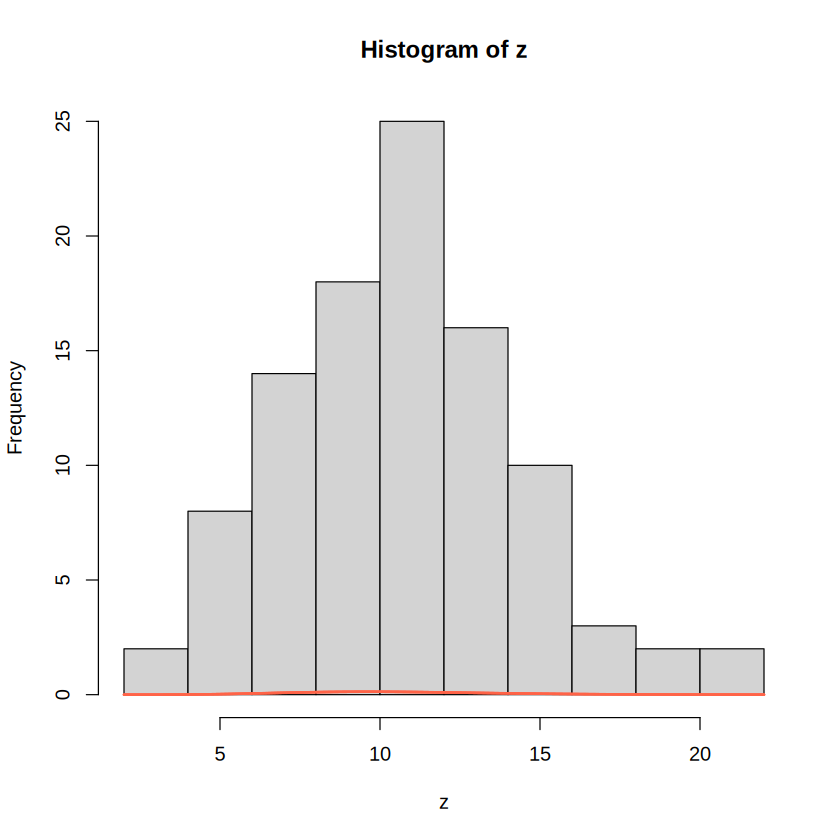

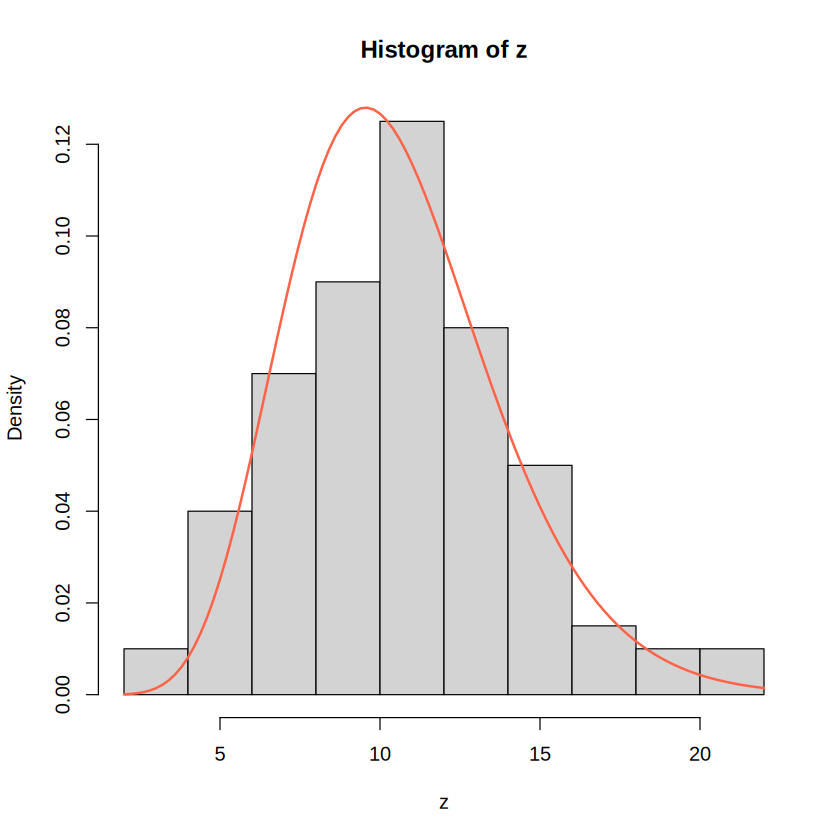

In [5]:
rm(list = ls())
n <- 100
theta0 <- 10
z <- rgamma(n, shape = theta0, scale = 1)
hist(z)

#Newton-Raphson
theta.hat = numeric()

# Chute inicial: Estimativa via método de momentos
theta.hat[1] = mean(z)

error = 1
j=0

while(error > 10 ^ (-5)) {
  j = j +1
  # First derivative of log-likelihood (U'(theta))
  U_prime <- sum(log(z)) - n * digamma(theta.hat[j])
  # Second derivative of log-likelihood (U''(theta))
  U_double_prime <- -n * trigamma(theta.hat[j])

  # Newton-Raphson update rule: theta_new = theta_old - U_prime / U_double_prime
  theta.hat[j+1] = theta.hat[j] - U_prime / U_double_prime

  error = abs(theta.hat[j+1] - theta.hat[j])
  print(paste("Iteration:", j, "Theta Hat:", round(theta.hat[j+1], 5)))

  f = function(z) dgamma(z, theta.hat[j])
  curve(f, add = TRUE, col= "tomato", lwd = 2)
  Sys.sleep(.1)
}

hist(z, probability = TRUE)
f = function(z) dgamma(z, theta.hat[j])
curve(f, add = TRUE, col= "tomato", lwd = 2)

In [ ]:
# dot his sam
theta.hat[j+1] = theta.hat[j] + delta * sum(log(z))/